# Data Quality Diagnostics Notebook
**Group 10 | nvd-snow-yolov9**

This notebook objectively diagnoses data quality issues — particularly the train/val vs test distribution mismatch.

### Objectives
1. **Label sanity** — Are labels valid YOLO format? Any empty/corrupt files?
2. **Image sanity** — Corrupt images, resolution consistency, channel issues
3. **Class distribution** — Are bboxes present and reasonably distributed across splits?
4. **Visual spot-check** — Show sample images with overlaid bboxes for each split
5. **Train/Val/Test distribution comparison** — Image statistics (brightness, contrast) to detect domain shift
6. **Test set deep-dive** — Why is test mAP ~0? Check if labels exist, if images are valid
7. **Prediction vs GT overlay** — Load best.pt and visualize what the model actually predicts on test images

In [1]:
import os
os.chdir('/project')

In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from collections import defaultdict
import json

# Dataset roots
YOLO_ROOT  = Path('/project/outputs/yolo')
IMG_ROOT   = YOLO_ROOT / 'images'
LBL_ROOT   = YOLO_ROOT / 'labels'
SPLITS     = ['train', 'val', 'test']

print('Paths:')
for s in SPLITS:
    n_img = len(list((IMG_ROOT / s).glob('*.png')) + list((IMG_ROOT / s).glob('*.jpg')))
    n_lbl = len(list((LBL_ROOT / s).glob('*.txt')))
    print(f'  {s:5s}: {n_img:5d} images | {n_lbl:5d} label files')

Paths:
  train:  6056 images |  6056 label files
  val  :  1203 images |  1203 label files
  test :   923 images |   923 label files


## 1. Label Sanity Check
YOLO labels must be: `class cx cy w h` all in [0,1]. Any deviation = broken data.

In [3]:
def check_labels(split):
    lbl_dir = LBL_ROOT / split
    img_dir = IMG_ROOT / split
    
    stats = {
        'total_label_files': 0,
        'empty_label_files': 0,         # files with 0 annotations
        'missing_label_files': 0,       # images with no .txt pair
        'corrupt_label_files': 0,       # malformed rows
        'out_of_range_coords': 0,       # cx/cy/w/h outside [0,1]
        'negative_dims': 0,             # w or h <= 0
        'total_annotations': 0,
        'bad_files': []                 # list of problem files
    }
    
    images = list(img_dir.glob('*.png')) + list(img_dir.glob('*.jpg'))
    
    for img_path in images:
        lbl_path = lbl_dir / (img_path.stem + '.txt')
        
        if not lbl_path.exists():
            stats['missing_label_files'] += 1
            stats['bad_files'].append(f'MISSING_LABEL: {img_path.name}')
            continue
        
        stats['total_label_files'] += 1
        lines = lbl_path.read_text().strip().splitlines()
        
        if len(lines) == 0:
            stats['empty_label_files'] += 1
            continue
        
        for line in lines:
            parts = line.strip().split()
            if len(parts) != 5:
                stats['corrupt_label_files'] += 1
                stats['bad_files'].append(f'CORRUPT_ROW: {lbl_path.name} → "{line}"')
                break
            try:
                cls, cx, cy, w, h = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                stats['total_annotations'] += 1
                
                # Check range
                if not (0 <= cx <= 1 and 0 <= cy <= 1 and 0 < w <= 1 and 0 < h <= 1):
                    stats['out_of_range_coords'] += 1
                    if len(stats['bad_files']) < 20:
                        stats['bad_files'].append(f'OUT_OF_RANGE: {lbl_path.name} → cx={cx:.3f} cy={cy:.3f} w={w:.3f} h={h:.3f}')
                
                if w <= 0 or h <= 0:
                    stats['negative_dims'] += 1
            except ValueError:
                stats['corrupt_label_files'] += 1
                stats['bad_files'].append(f'PARSE_ERROR: {lbl_path.name}')
    
    return stats


print('=' * 65)
print(f'LABEL SANITY CHECK')
print('=' * 65)

all_stats = {}
for split in SPLITS:
    s = check_labels(split)
    all_stats[split] = s
    print(f'\n[{split.upper()}]')
    print(f'  Label files         : {s["total_label_files"]}')
    print(f'  Total annotations   : {s["total_annotations"]}')
    print(f'  Empty label files   : {s["empty_label_files"]}  ← should be 0 or expected background')
    print(f'  Missing label files : {s["missing_label_files"]}  ← PROBLEM if > 0')
    print(f'  Corrupt rows        : {s["corrupt_label_files"]}  ← PROBLEM if > 0')
    print(f'  Out-of-range coords : {s["out_of_range_coords"]}  ← PROBLEM if > 0')
    print(f'  Negative dims       : {s["negative_dims"]}  ← PROBLEM if > 0')
    if s['bad_files']:
        print(f'  ⚠ First bad entries:')
        for bf in s['bad_files'][:5]:
            print(f'    {bf}')

print('\n' + '=' * 65)

LABEL SANITY CHECK

[TRAIN]
  Label files         : 6056
  Total annotations   : 18956
  Empty label files   : 0  ← should be 0 or expected background
  Missing label files : 0  ← PROBLEM if > 0
  Corrupt rows        : 0  ← PROBLEM if > 0
  Out-of-range coords : 0  ← PROBLEM if > 0
  Negative dims       : 0  ← PROBLEM if > 0

[VAL]
  Label files         : 1203
  Total annotations   : 4168
  Empty label files   : 0  ← should be 0 or expected background
  Missing label files : 0  ← PROBLEM if > 0
  Corrupt rows        : 0  ← PROBLEM if > 0
  Out-of-range coords : 0  ← PROBLEM if > 0
  Negative dims       : 0  ← PROBLEM if > 0

[TEST]
  Label files         : 923
  Total annotations   : 2455
  Empty label files   : 0  ← should be 0 or expected background
  Missing label files : 0  ← PROBLEM if > 0
  Corrupt rows        : 0  ← PROBLEM if > 0
  Out-of-range coords : 0  ← PROBLEM if > 0
  Negative dims       : 0  ← PROBLEM if > 0



## 2. Image Sanity Check
Check for corrupt images, inconsistent sizes, and grayscale vs RGB issues.

In [4]:
def check_images(split, sample_n=200):
    img_dir = IMG_ROOT / split
    images  = list(img_dir.glob('*.png')) + list(img_dir.glob('*.jpg'))
    
    # Sample if too many
    if len(images) > sample_n:
        rng = np.random.default_rng(42)
        images = list(rng.choice(images, sample_n, replace=False))
    
    stats = {
        'total': len(images),
        'corrupt': 0,
        'truncated': 0,
        'sizes': [],
        'channels': defaultdict(int),
        'mean_brightness': [],
        'mean_contrast': [],
        'bad_files': []
    }
    
    for p in images:
        img = cv2.imread(str(p))
        if img is None:
            stats['corrupt'] += 1
            stats['bad_files'].append(f'UNREADABLE: {p.name}')
            continue
        
        h, w = img.shape[:2]
        c = img.shape[2] if img.ndim == 3 else 1
        
        if h < 32 or w < 32:
            stats['truncated'] += 1
            stats['bad_files'].append(f'TINY({w}x{h}): {p.name}')
        
        stats['sizes'].append((w, h))
        stats['channels'][c] += 1
        
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(float)
        stats['mean_brightness'].append(gray.mean())
        stats['mean_contrast'].append(gray.std())
    
    return stats


print('IMAGE SANITY CHECK (sampled 200 per split)')
print('=' * 65)

img_stats = {}
for split in SPLITS:
    s = check_images(split)
    img_stats[split] = s
    sizes = s['sizes']
    widths  = [sz[0] for sz in sizes]
    heights = [sz[1] for sz in sizes]
    
    print(f'\n[{split.upper()}]')
    print(f'  Sampled             : {s["total"]}')
    print(f'  Corrupt (unreadable): {s["corrupt"]}  ← PROBLEM if > 0')
    print(f'  Tiny images (<32px) : {s["truncated"]}  ← PROBLEM if > 0')
    if widths:
        print(f'  Width  range        : {min(widths)} – {max(widths)} px  (median {int(np.median(widths))})')
        print(f'  Height range        : {min(heights)} – {max(heights)} px  (median {int(np.median(heights))})')
    print(f'  Channels            : {dict(s["channels"])}')
    if s['mean_brightness']:
        print(f'  Brightness  mean±std: {np.mean(s["mean_brightness"]):.1f} ± {np.std(s["mean_brightness"]):.1f}  (range: {np.min(s["mean_brightness"]):.1f}–{np.max(s["mean_brightness"]):.1f})')
        print(f'  Contrast    mean±std: {np.mean(s["mean_contrast"]):.1f} ± {np.std(s["mean_contrast"]):.1f}')
    if s['bad_files']:
        print(f'  ⚠ Bad files (first 5):')
        for bf in s['bad_files'][:5]:
            print(f'    {bf}')

print('\n' + '=' * 65)

IMAGE SANITY CHECK (sampled 200 per split)

[TRAIN]
  Sampled             : 200
  Corrupt (unreadable): 0  ← PROBLEM if > 0
  Tiny images (<32px) : 0  ← PROBLEM if > 0
  Width  range        : 1920 – 1920 px  (median 1920)
  Height range        : 1080 – 1080 px  (median 1080)
  Channels            : {3: 200}
  Brightness  mean±std: 104.9 ± 21.8  (range: 25.8–132.2)
  Contrast    mean±std: 52.3 ± 6.9

[VAL]
  Sampled             : 200
  Corrupt (unreadable): 0  ← PROBLEM if > 0
  Tiny images (<32px) : 0  ← PROBLEM if > 0
  Width  range        : 1920 – 1920 px  (median 1920)
  Height range        : 1080 – 1080 px  (median 1080)
  Channels            : {3: 200}
  Brightness  mean±std: 96.6 ± 12.7  (range: 53.4–122.4)
  Contrast    mean±std: 64.0 ± 6.7


libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error



[TEST]
  Sampled             : 200
  Corrupt (unreadable): 23  ← PROBLEM if > 0
  Tiny images (<32px) : 0  ← PROBLEM if > 0
  Width  range        : 1920 – 1920 px  (median 1920)
  Height range        : 1080 – 1080 px  (median 1080)
  Channels            : {3: 177}
  Brightness  mean±std: 75.0 ± 14.2  (range: 21.2–108.6)
  Contrast    mean±std: 49.4 ± 5.5
  ⚠ Bad files (first 5):
    UNREADABLE: 2022-12-23_Bjenberg_02_stabilized_frame_000178.png
    UNREADABLE: 2022-12-23_Bjenberg_02_stabilized_frame_000148.png
    UNREADABLE: 2022-12-23_Bjenberg_02_stabilized_frame_000094.png
    UNREADABLE: 2022-12-23_Bjenberg_02_stabilized_frame_000154.png
    UNREADABLE: 2022-12-23_Bjenberg_02_stabilized_frame_000165.png



libpng error: Read Error


## 3. Distribution Comparison Plot
Compare brightness and contrast distributions across train/val/test. If test looks very different from train → domain shift.

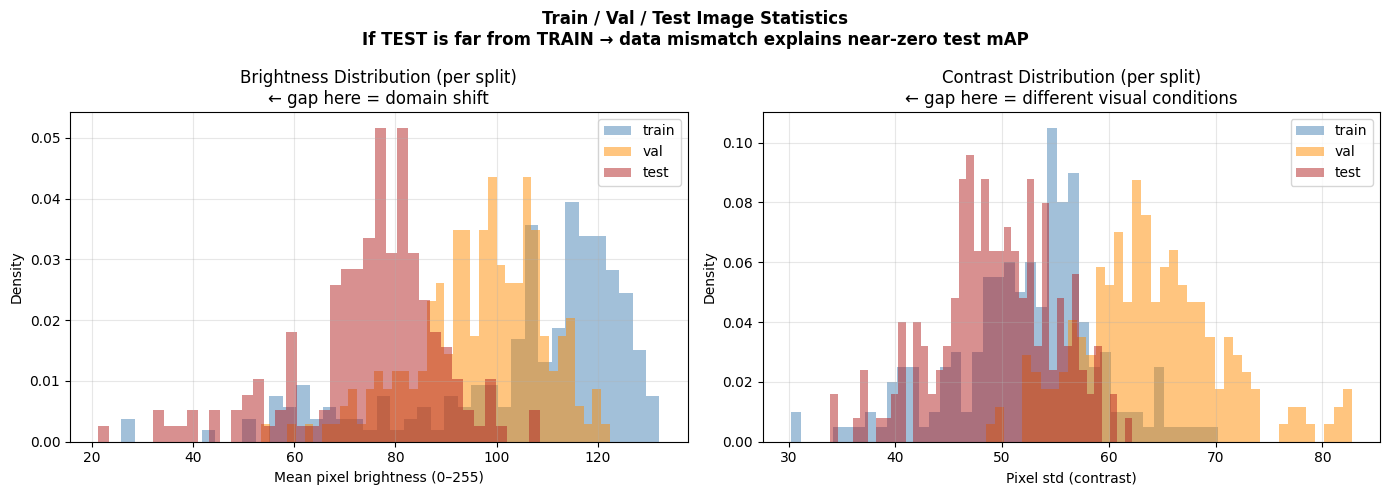

Saved: /project/outputs/results/diag_brightness_contrast.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'train': 'steelblue', 'val': 'darkorange', 'test': 'firebrick'}

for split in SPLITS:
    s = img_stats[split]
    if s['mean_brightness']:
        axes[0].hist(s['mean_brightness'], bins=40, alpha=0.5, color=colors[split], label=split, density=True)
        axes[1].hist(s['mean_contrast'],   bins=40, alpha=0.5, color=colors[split], label=split, density=True)

axes[0].set_title('Brightness Distribution (per split)\n← gap here = domain shift')
axes[0].set_xlabel('Mean pixel brightness (0–255)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title('Contrast Distribution (per split)\n← gap here = different visual conditions')
axes[1].set_xlabel('Pixel std (contrast)')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Train / Val / Test Image Statistics\n'
             'If TEST is far from TRAIN → data mismatch explains near-zero test mAP',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/project/outputs/results/diag_brightness_contrast.png', dpi=120)
plt.show()
print('Saved: /project/outputs/results/diag_brightness_contrast.png')

## 4. Annotation Density Per Split
How many bboxes per image? If test has very different density → label mismatch.

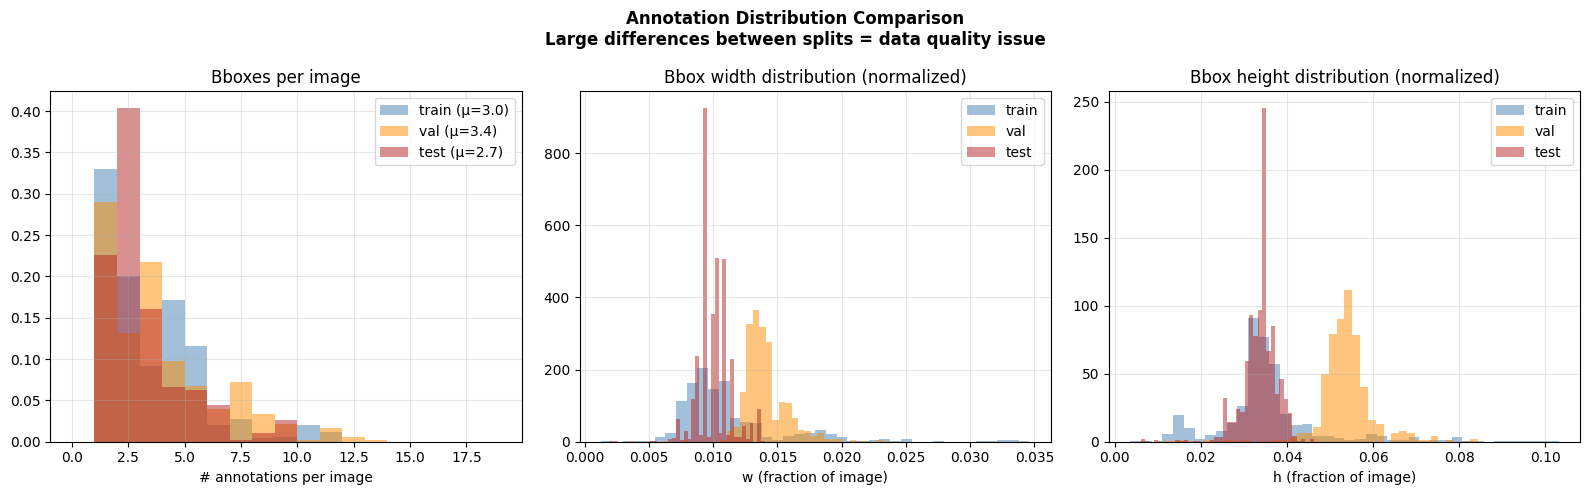

Saved: /project/outputs/results/diag_bbox_distribution.png


In [6]:
def get_bbox_counts(split, max_files=500):
    lbl_dir = LBL_ROOT / split
    files = list(lbl_dir.glob('*.txt'))
    if len(files) > max_files:
        rng = np.random.default_rng(42)
        files = list(rng.choice(files, max_files, replace=False))
    
    counts = []
    box_widths  = []
    box_heights = []
    
    for f in files:
        lines = f.read_text().strip().splitlines()
        valid = [l for l in lines if len(l.strip().split()) == 5]
        counts.append(len(valid))
        for l in valid:
            try:
                _, cx, cy, w, h = l.strip().split()
                box_widths.append(float(w))
                box_heights.append(float(h))
            except:
                pass
    
    return counts, box_widths, box_heights


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for split in SPLITS:
    counts, bw, bh = get_bbox_counts(split)
    color = colors[split]
    
    axes[0].hist(counts, bins=range(0, 20), alpha=0.5, color=color, label=f'{split} (μ={np.mean(counts):.1f})', density=True)
    if bw:
        axes[1].hist(bw, bins=40, alpha=0.5, color=color, label=split, density=True)
        axes[2].hist(bh, bins=40, alpha=0.5, color=color, label=split, density=True)

axes[0].set_title('Bboxes per image')
axes[0].set_xlabel('# annotations per image')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title('Bbox width distribution (normalized)')
axes[1].set_xlabel('w (fraction of image)')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].set_title('Bbox height distribution (normalized)')
axes[2].set_xlabel('h (fraction of image)')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Annotation Distribution Comparison\nLarge differences between splits = data quality issue',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/project/outputs/results/diag_bbox_distribution.png', dpi=120)
plt.show()
print('Saved: /project/outputs/results/diag_bbox_distribution.png')

## 5. Visual Spot-Check — Sample Images with GT Boxes
Visually inspect ground-truth labels overlaid on images for each split.

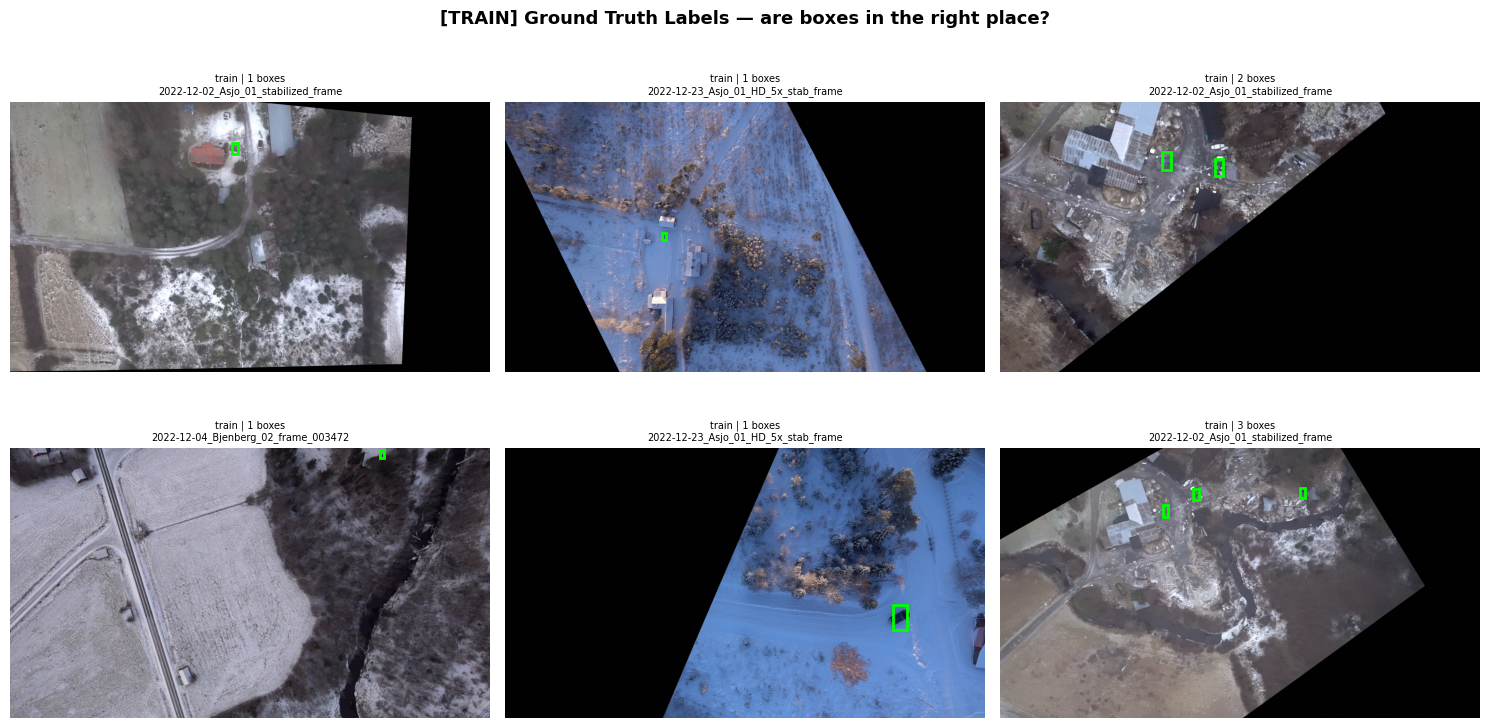

Saved: /project/outputs/results/diag_gt_samples_train.png


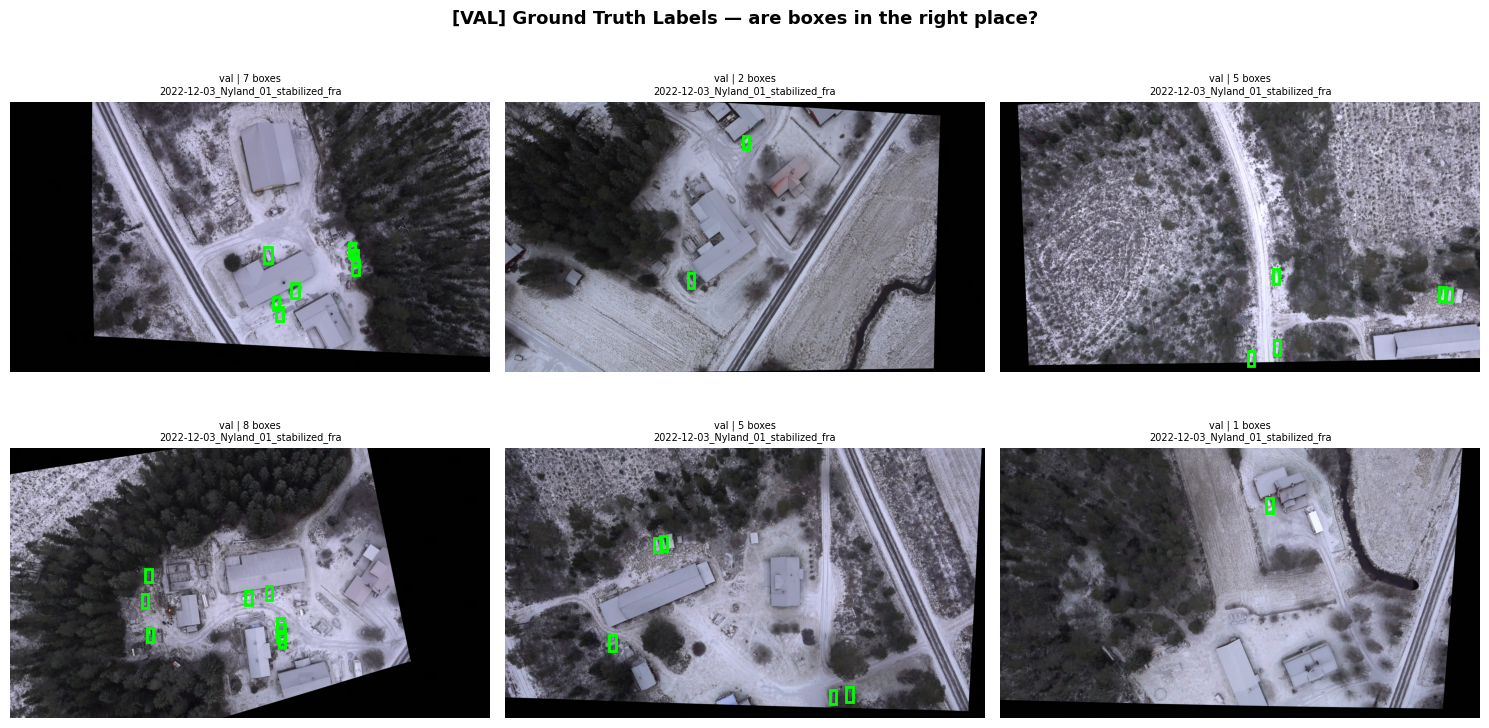

Saved: /project/outputs/results/diag_gt_samples_val.png


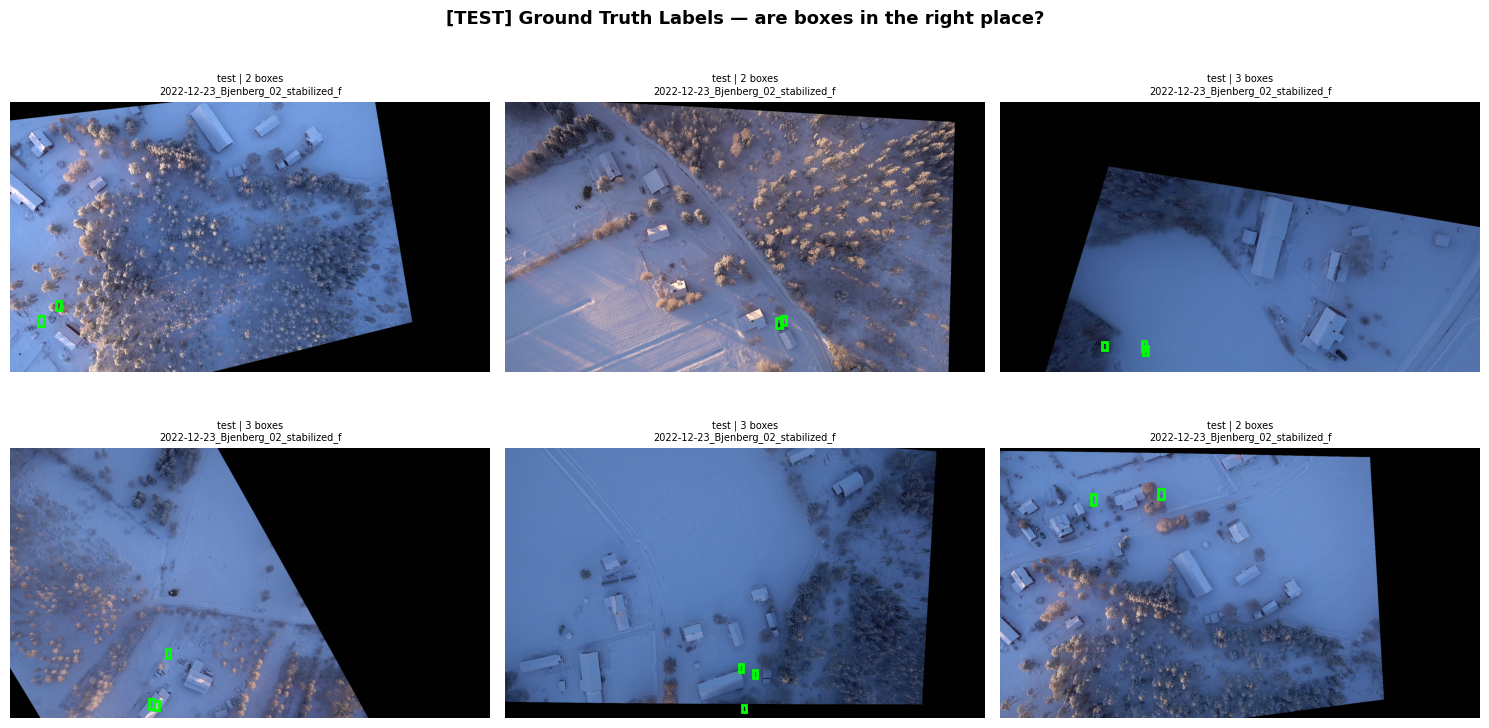

Saved: /project/outputs/results/diag_gt_samples_test.png


In [7]:
def show_samples_with_gt(split, n=6, seed=42):
    img_dir = IMG_ROOT / split
    lbl_dir = LBL_ROOT / split
    
    images = list(img_dir.glob('*.png')) + list(img_dir.glob('*.jpg'))
    rng    = np.random.default_rng(seed)
    
    # Prefer images that have annotations
    annotated = [p for p in images if (lbl_dir / (p.stem + '.txt')).exists()
                 and len((lbl_dir / (p.stem + '.txt')).read_text().strip()) > 0]
    
    pool  = annotated if len(annotated) >= n else images
    picks = list(rng.choice(pool, min(n, len(pool)), replace=False))
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    for i, img_path in enumerate(picks):
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]
        
        axes[i].imshow(img)
        axes[i].set_title(img_path.name[:40], fontsize=7)
        axes[i].axis('off')
        
        lbl_path = lbl_dir / (img_path.stem + '.txt')
        n_boxes  = 0
        if lbl_path.exists():
            for line in lbl_path.read_text().strip().splitlines():
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                _, cx, cy, w, h = float(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                x1 = (cx - w / 2) * W
                y1 = (cy - h / 2) * H
                rect = patches.Rectangle((x1, y1), w * W, h * H,
                                         linewidth=2, edgecolor='lime', facecolor='none')
                axes[i].add_patch(rect)
                n_boxes += 1
        
        axes[i].set_title(f'{split} | {n_boxes} boxes\n{img_path.name[:35]}', fontsize=7)
    
    plt.suptitle(f'[{split.upper()}] Ground Truth Labels — are boxes in the right place?',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'/project/outputs/results/diag_gt_samples_{split}.png', dpi=120)
    plt.show()
    print(f'Saved: /project/outputs/results/diag_gt_samples_{split}.png')


for split in SPLITS:
    show_samples_with_gt(split)

## 6. Test Set Deep-Dive — The Smoking Gun
The val mAP is 0.33 but test is ~0. Let's find out exactly why.

In [8]:
# ── 6a. Check what % of test images are in the 'corrupt' list ────────────────
test_img_dir = IMG_ROOT / 'test'
test_lbl_dir = LBL_ROOT / 'test'

test_images = list(test_img_dir.glob('*.png')) + list(test_img_dir.glob('*.jpg'))

readable, unreadable, with_labels, without_labels, zero_bbox, has_bbox = 0, 0, 0, 0, 0, 0
sample_unreadable = []
sample_zero_bbox  = []

for p in test_images:
    img = cv2.imread(str(p))
    if img is None:
        unreadable += 1
        if len(sample_unreadable) < 5:
            sample_unreadable.append(p.name)
    else:
        readable += 1
    
    lbl = test_lbl_dir / (p.stem + '.txt')
    if lbl.exists():
        with_labels += 1
        lines = [l for l in lbl.read_text().strip().splitlines() if len(l.strip().split()) == 5]
        if len(lines) == 0:
            zero_bbox += 1
            if len(sample_zero_bbox) < 5:
                sample_zero_bbox.append(p.name)
        else:
            has_bbox += 1
    else:
        without_labels += 1

total = len(test_images)
print('TEST SET DEEP-DIVE')
print('=' * 55)
print(f'  Total test images    : {total}')
print(f'  Readable by OpenCV   : {readable}  ({100*readable/total:.1f}%)')
print(f'  ⚠ UNREADABLE         : {unreadable}  ({100*unreadable/total:.1f}%)  ← these count as wrong predictions')
print(f'  Have a .txt label    : {with_labels}  ({100*with_labels/total:.1f}%)')
print(f'  Missing .txt label   : {without_labels}  ← PROBLEM: model evaluated without GT')
print(f'  Label exists but 0 bbox: {zero_bbox}  ← background images, OK if expected')
print(f'  Has ≥1 annotated bbox: {has_bbox}  ({100*has_bbox/total:.1f}%)')

if sample_unreadable:
    print(f'\n  Example unreadable files:')
    for f in sample_unreadable:
        print(f'    {f}')

if sample_zero_bbox:
    print(f'\n  Example zero-bbox label files:')
    for f in sample_zero_bbox:
        print(f'    {f}')

print('\n  DIAGNOSIS:')
if unreadable / total > 0.05:
    print(f'  {unreadable} corrupt images ({100*unreadable/total:.0f}%) in test set — this directly tanks mAP')
if without_labels > 0:
    print(f'  {without_labels} images have no label file — model has no GT to compare against')
if has_bbox / total < 0.5:
    print(f'  Only {100*has_bbox/total:.0f}% of test images have any annotation — evaluation is broken')
if unreadable == 0 and without_labels == 0 and has_bbox / total > 0.8:
    print(f'  Test images and labels look structurally OK — issue may be visual domain shift')

libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error


TEST SET DEEP-DIVE
  Total test images    : 923
  Readable by OpenCV   : 819  (88.7%)
  ⚠ UNREADABLE         : 104  (11.3%)  ← these count as wrong predictions
  Have a .txt label    : 923  (100.0%)
  Missing .txt label   : 0  ← PROBLEM: model evaluated without GT
  Label exists but 0 bbox: 0  ← background images, OK if expected
  Has ≥1 annotated bbox: 923  (100.0%)

  Example unreadable files:
    2022-12-23_Bjenberg_02_stabilized_frame_000091.png
    2022-12-23_Bjenberg_02_stabilized_frame_000208.png
    2022-12-23_Bjenberg_02_stabilized_frame_001383.png
    2022-12-23_Bjenberg_02_stabilized_frame_001391.png
    2022-12-23_Bjenberg_02_stabilized_frame_000673.png

  DIAGNOSIS:
  ❌ 104 corrupt images (11%) in test set — this directly tanks mAP


In [9]:
# ── 6b. File naming check ─────────────────────────────────────────────────────
# YOLO pairs images to labels by replacing /images/ with /labels/ and extension with .txt
# A common bug: image is .jpg but label is .txt looked up from .png path (or vice versa)

print('FILE NAMING CONSISTENCY CHECK')
print('=' * 55)
for split in SPLITS:
    img_dir = IMG_ROOT / split
    lbl_dir = LBL_ROOT / split
    
    imgs = {p.stem: p.suffix for p in list(img_dir.glob('*.png')) + list(img_dir.glob('*.jpg'))}
    lbls = {p.stem for p in lbl_dir.glob('*.txt')}
    
    imgs_no_label = set(imgs.keys()) - lbls
    lbls_no_image = lbls - set(imgs.keys())
    
    print(f'\n[{split.upper()}]')
    print(f'  Image stems    : {len(imgs)}')
    print(f'  Label stems    : {len(lbls)}')
    print(f'  Images without matching .txt : {len(imgs_no_label)}')
    print(f'  .txt files without matching image : {len(lbls_no_image)}')
    
    if imgs_no_label:
        sample = list(imgs_no_label)[:3]
        print(f'  ⚠ Example images with no label: {sample}')
    if lbls_no_image:
        sample = list(lbls_no_image)[:3]
        print(f'  ⚠ Example orphan labels: {sample}')

FILE NAMING CONSISTENCY CHECK

[TRAIN]
  Image stems    : 6056
  Label stems    : 6056
  Images without matching .txt : 0
  .txt files without matching image : 0

[VAL]
  Image stems    : 1203
  Label stems    : 1203
  Images without matching .txt : 0
  .txt files without matching image : 0

[TEST]
  Image stems    : 923
  Label stems    : 923
  Images without matching .txt : 0
  .txt files without matching image : 0


## 7. Model Prediction vs GT on Test Images
Load the trained best.pt and see what it actually predicts on test images.
If predictions look reasonable but GT is wrong → label problem.
If predictions are garbage → model genuinely fails on this domain.

In [ ]:
from ultralytics import YOLO

model_path = '/project/outputs/results/v1/weights/best.pt'
model = YOLO(model_path)

test_img_dir = IMG_ROOT / 'test'
test_lbl_dir = LBL_ROOT / 'test'

# Pick readable test images that have annotations
candidates = []
for p in list(test_img_dir.glob('*.png')) + list(test_img_dir.glob('*.jpg')):
    img = cv2.imread(str(p))
    if img is None:
        continue
    lbl = test_lbl_dir / (p.stem + '.txt')
    if lbl.exists() and len(lbl.read_text().strip()) > 0:
        candidates.append(p)

rng   = np.random.default_rng(42)
picks = list(rng.choice(candidates, min(6, len(candidates)), replace=False))

print(f'Running inference on {len(picks)} test images...')

fig, axes = plt.subplots(len(picks), 2, figsize=(14, 4 * len(picks)))
if len(picks) == 1:
    axes = [axes]

for row, img_path in enumerate(picks):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    H, W    = img_rgb.shape[:2]
    
    # ── Left: Ground Truth ──────────────────────────────────────
    ax_gt = axes[row][0]
    ax_gt.imshow(img_rgb)
    ax_gt.set_title(f'GT — {img_path.name[:40]}', fontsize=7)
    ax_gt.axis('off')
    
    lbl_path = test_lbl_dir / (img_path.stem + '.txt')
    n_gt = 0
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().splitlines():
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            _, cx, cy, w, h = [float(x) for x in parts]
            x1 = (cx - w/2) * W
            y1 = (cy - h/2) * H
            rect = patches.Rectangle((x1, y1), w*W, h*H,
                                      linewidth=2, edgecolor='lime', facecolor='none')
            ax_gt.add_patch(rect)
            n_gt += 1
    ax_gt.set_title(f'GT ({n_gt} boxes) | {img_path.name[:30]}', fontsize=7)
    
    # ── Right: Model Predictions ────────────────────────────────
    ax_pred = axes[row][1]
    ax_pred.imshow(img_rgb)
    ax_pred.axis('off')
    
    results = model.predict(str(img_path), conf=0.1, verbose=False)
    boxes   = results[0].boxes
    n_pred  = 0
    if boxes is not None and len(boxes) > 0:
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf = float(box.conf[0])
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                      linewidth=2, edgecolor='red', facecolor='none')
            ax_pred.add_patch(rect)
            ax_pred.text(x1, y1-4, f'{conf:.2f}', color='red', fontsize=7)
            n_pred += 1
    ax_pred.set_title(f'Pred ({n_pred} boxes, conf≥0.1)', fontsize=8)

plt.suptitle('Ground Truth (green) vs Model Predictions (red) on TEST images\n'
             'GT boxes should align with cars. If GT is wrong/missing → label problem.',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('/project/outputs/results/diag_pred_vs_gt_test.png', dpi=120)
plt.show()
print('Saved: /project/outputs/results/diag_pred_vs_gt_test.png')

libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error


## 8. Summary Report

In [ ]:
print('\n' + '='*70)
print('  DATA QUALITY DIAGNOSTIC SUMMARY')
print('='*70)

issues = []
ok     = []

for split in SPLITS:
    s = all_stats[split]
    im = img_stats[split]
    
    if s['missing_label_files'] > 0:
        issues.append(f'[{split}] {s["missing_label_files"]} images have NO label file')
    else:
        ok.append(f'[{split}] All images have label files')
    
    if s['corrupt_label_files'] > 0:
        issues.append(f'[{split}] {s["corrupt_label_files"]} CORRUPT label rows found')
    else:
        ok.append(f'[{split}] No corrupt label rows')
    
    if s['out_of_range_coords'] > 0:
        issues.append(f'[{split}] {s["out_of_range_coords"]} out-of-range bbox coordinates')
    else:
        ok.append(f'[{split}] All bbox coords in valid range [0,1]')
    
    if im['corrupt'] > 0:
        issues.append(f'[{split}] {im["corrupt"]} unreadable images')
    else:
        ok.append(f'[{split}] All sampled images are readable')

# Distribution comparison
train_bright = np.mean(img_stats['train']['mean_brightness']) if img_stats['train']['mean_brightness'] else 0
test_bright  = np.mean(img_stats['test']['mean_brightness'])  if img_stats['test']['mean_brightness']  else 0
bright_gap   = abs(train_bright - test_bright)

if bright_gap > 20:
    issues.append(f'DOMAIN SHIFT: Train brightness={train_bright:.1f} vs Test brightness={test_bright:.1f} — gap={bright_gap:.1f} (>20 is significant)')
else:
    ok.append(f'Brightness gap train vs test = {bright_gap:.1f} (within 20, acceptable)')

print('\n PASSING:')
for item in ok:
    print(f'     {item}')

print('\n PROBLEMS FOUND:')
if issues:
    for item in issues:
        print(f'     {item}')
else:
    print('     None found structurally — problem is likely VISUAL DOMAIN SHIFT')
    print('     Check the brightness/contrast plots and GT vs Pred images above')
    print('     Test frames may be from a different scene/condition than train')
print('='*70)